In [1]:
import numpy as np
from utilities import utils_tomo as utils
import matplotlib.pyplot as plt
from scipy.signal import windows
from scipy.ndimage import convolve
from alignment import tomoconsistency_tools_oriol as tc

No module named 'tomopy.recon'
No module named 'recast_tomo'


In [ ]:
folder = '/dls/i13-1/data/2025/cm40629-1/processing/ptycho-tomo_alignment/connor_wright'
filename = folder + '/scan_275019_275199_tomo_complex.nxs'
data_key = '/entry1/data'
angle_key = '/entry1/rotation_angle'

stack_object, theta, _ = utils.load_data(filename, data_key= data_key, angle_key = angle_key)
print(stack_object.shape)
stack_object = stack_object.transpose((1,2,0))
print(stack_object.shape)

raw data shape: (181, 582, 740)


In [3]:
# Defining some initial parameters
wavelength = 1.0597e-10 # [m]
pixel_size = 1.64e-8 # size of projection pixels [m]
asize = [150, 150] # size of the illumination probe in ptychography used to find "reliability" region

factor = wavelength/(2*np.pi*pixel_size)
factor_edensity = 1e-30*2*np.pi/(wavelength**2*2.81794e-15)

vert_crop  = asize[0]//2  #use default cropping equal to half of probe size removed from each side
horiz_crop = asize[1]//2  #use default cropping equal to half of probe size removed from each side 
illum_sum = np.ones((stack_object.shape[0], stack_object.shape[1]))  # reliability weights for the measured projections 
                                                                    # are assumed to be flat in our example 
scanstomo = np.arange(0,stack_object.shape[-1]) #scan numbers 

# Other
showsorted = True # sort plotted projections by angles, it has not effect on the alignment itself 
air_gap = [50,50] # very roughly distance around sides where is assumed air, it is used only for initial guess       

In [4]:
### Reconstruction
[Ny, Nx, Nangles] = stack_object.shape
object_ROI = [np.ceil(np.arange(1+vert_crop, Ny-vert_crop)), 
              np.ceil(np.arange(1+horiz_crop, Nx-horiz_crop))]

# Make data easily splitable for ASTRA, preferable size of blocks should be dividable by 32
width_sinogram = np.ceil(len(object_ROI[1])/32)*32
Nlayers = np.floor(len(object_ROI[0])/32)*32
Nroi = [len(object_ROI[0]),len(object_ROI[1])]

object_ROI = [object_ROI[0][int(np.ceil(Nroi[0]/2))]+np.arange(-Nlayers/2,Nlayers/2),
              object_ROI[1][int(np.ceil(Nroi[1]/2))]+np.arange(-width_sinogram/2,width_sinogram/2)]

Get phase gradient
Get mask
Done


(<AxesSubplot:>, <matplotlib.image.AxesImage at 0x7f0d5e320bb0>)

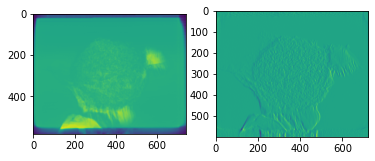

In [5]:
### Tomoconsistency alignment

# Reconstruction parameters
Npix = np.ceil(1.0*width_sinogram/32)*32 # for pillar it can be the same as width_sinogram
vert_range = np.arange(32,Nlayers-33) # selected vertical layers for alignment 

# Other parameters
max_binning = 2 ** np.ceil(np.log2(np.max(Npix))- np.log2(100)) # prevent binning to make smaller object than 100 pixels, 
                                                                # reconstruction gets unstable 
min_binning = np.minimum(max_binning, 2) # originally "min(max_binning, 2^par.online_tomo"

# Useful tuning parameters
high_pass_filter = 0.01 # remove effect of residuums/bad ptycho convergence, 
                        # high value may get stack in local minima, low value increases sensitivity to residua / phase jumps 

# In case of problems you can also change 
momentum_acceleration = True # accelerate convergence by momentum gradient descent method, 
                            # set to false in case the the convergence is failing
apply_positivity = True # remove negative values in the reconstructed volume, helps with alignment especially for sparser samples, 
                        # it can cause problems if the unwrapped phase contain low spatial frequency errors (-> positivity constraint is not valid anymore)

# Other settings 
showsorted = True # selected angular order for alignment 
valid_angles = np.arange(1,Nangles) > 0 # use only these indices to do reconstruction (with respect to the time sorted angles)
center_reconstruction = True # keep the center of mass of the reconstructed sample in center of 3D field of view
align_horizontal = True # horizontal alignment 
align_vertical = False # vertical alignment, usually only a small correction of initial guess  
use_mask = False # apply support mask on the reconstructed sample volume 
mask_threshold = 0.001 # []== Otsu thresholding, otherwise the value is in phase tomogram reconstruction 
use_localTV = False # apply local TV into the reconstructed volume, should help with convergence  
apply_positivity = True # remove negative values in the reconstructed volume, helps with alignment especially for sparser samples 
min_step_size  = 0.01 # stopping criterion (subpixel precision)
max_iter = 100 # maximal number of iterations
use_Xcorr_outlier_check = True; # in the first iteration check and remove outliers using Xcorr 
refine_geometry = False # try to find better geoometry to fit the data

# Internal parameters, do not change if you are not sure 
step_relaxation = 0.5 # gradient descent step relaxation, (1 == full step), value <1 may be needed to avoid oscilations  
filter_type = 'ram-lak' # FBP filter (ram-lak, hamming, ....)
freq_scale = 1 # Frequency cutoff for the FBP filters, 1 == no FBP filtering
unwrap_data_method = 'fft_1d' # Unwrap method: fft_2d, fft_1d, none - assume that provided sinogram is already unwrapped 

# Generate inputs for tomoconsistency alignment
print('Get phase gradient')
# solve the function blockwise on GPU 
# MATLAB: sinogram = tomo.block_fun(@math.get_phase_gradient_1D, stack_object, 2, struct('GPU_list', par.GPU_list, 'ROI', {object_ROI}, 'use_fp16', false)); 
sinogram = tc.get_phase_gradient_1D(stack_object,ax=1)

print('Get mask')
# include the effect of high pass filter into the weights 
size = np.maximum(3, int(np.ceil(high_pass_filter * width_sinogram)))
gauss_window = windows.gaussian(size, std = size/6)
hanning_window = windows.hann(3)
ker = gauss_window.reshape(-1,1) * hanning_window

# relevance weights -> remove effect of potential residues / phase jumps 
ker2 = ker[np.newaxis,:,:]
convolution_result = convolve((np.abs(sinogram) > 2).astype(np.float32), ker2.astype(np.float32), mode = 'constant', cval = 0.0)
sino_weights = np.maximum(0,1-convolution_result)
print('Done')

plt.figure()
plt.subplot(1,2,1),plt.imshow(np.imag(stack_object[:,:,0]))
plt.subplot(1,2,2),plt.imshow(sinogram[:,:,0])

In [3]:
translation_test = np.zeros((181,2))
translation_test[:,0] = 100 # x
translation_test[:,1] = 200 # y

In [5]:
img_shifted = tc.imshift_linear_ax(stack_object,100,1)

TypeError: 'int' object is not subscriptable

(<AxesSubplot:>, <matplotlib.image.AxesImage at 0x7fac8eb47040>)

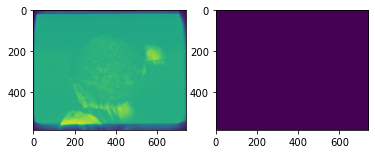

In [5]:
plt.figure()
plt.subplot(1,2,1), plt.imshow(np.imag(stack_object[:,:,0]))
plt.subplot(1,2,2), plt.imshow(np.imag(img_shifted[:,:,0]))

In [6]:
print(np.mean(img_shifted))

-0.022148377635529654


In [7]:
np.isrealobj(stack_object)

False